In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from torch import optim
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
import random

## Data Loading and Cleaning

In [391]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [2]:
df = pd.read_csv("NIFTY50_all.csv", parse_dates=["Date"])

#Keep only relevant columns
df = df[["Date", "Symbol", "Close"]]

df.head()

NameError: name 'pd' is not defined

In [393]:
prices = df.pivot(index="Date", columns="Symbol", values="Close")
prices.head()

Symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJAUTOFIN,BAJFINANCE,BHARTI,BHARTIARTL,BPCL,...,TISCO,TITAN,ULTRACEMCO,UNIPHOS,UPL,UTIBANK,VEDL,WIPRO,ZEEL,ZEETELE
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,381.65,NaN,NaN,NaN,50.75,NaN,NaN,NaN,399.25,...,152.45,155.70,NaN,NaN,NaN,26.70,NaN,2724.20,NaN,1179.95
2000-01-04,NaN,385.55,NaN,NaN,NaN,48.10,NaN,NaN,NaN,370.50,...,150.80,147.40,NaN,NaN,NaN,26.85,NaN,2942.15,NaN,1260.65
2000-01-05,NaN,383.00,NaN,NaN,NaN,44.60,NaN,NaN,NaN,359.95,...,156.55,138.40,NaN,NaN,NaN,26.30,NaN,2990.10,NaN,1176.55
2000-01-06,NaN,377.50,NaN,NaN,NaN,45.25,NaN,NaN,NaN,380.30,...,168.25,149.50,NaN,NaN,NaN,25.95,NaN,2932.25,NaN,1115.45
2000-01-07,NaN,385.70,NaN,NaN,NaN,42.90,NaN,NaN,NaN,379.85,...,171.95,146.35,NaN,NaN,NaN,24.80,NaN,2697.70,NaN,1026.25


In [394]:
start_date = "2007-01-01"
end_date = "2019-12-31"
prices = prices.loc[start_date:end_date]

In [1]:
prices.shape

NameError: name 'prices' is not defined

In [395]:
valid_stocks = prices.iloc[0].dropna().index
prices = prices[valid_stocks]

In [396]:
print(f"Dropped {len(df['Symbol'].unique()) - len(valid_stocks)} stocks because they weren't listed by {start_date}.")

Dropped 22 stocks because they weren't listed by 2007-01-01.


In [397]:
na_cols = list(prices.columns[prices.isnull().sum() > 0])

In [398]:
prices.drop(columns=na_cols, inplace=True)

Plotting the closing prices for first 5 stocks.

<Axes: xlabel='Date'>

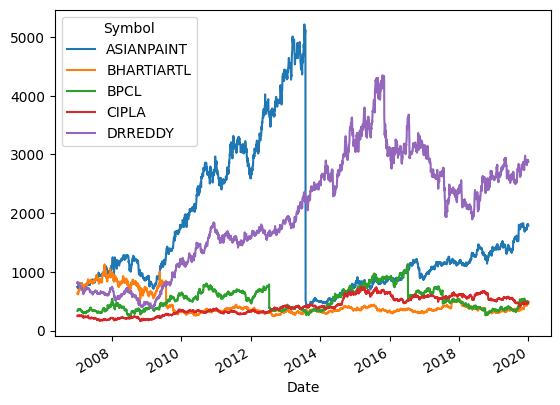

In [399]:
prices.iloc[:,:5].plot()

### Concatanate the daily returns and standardize the data

In [400]:
split_idx = int(len(prices) * 0.8)
val_split = int(len(prices) * 0.1)

train_prices = prices.iloc[:split_idx]
val_prices = prices.iloc[split_idx:split_idx+val_split]
test_prices = prices.iloc[split_idx+val_split:]


In [401]:
def standardize_train(data):
    # scale prices and returns in train set
    scaler = StandardScaler()
    data = scaler.fit_transform(data)
    data = pd.DataFrame(data, columns=scaler.get_feature_names_out())
    return scaler , data 

def standardize(data,scaler):
    data = scaler.transform(data)
    data = pd.DataFrame(data, columns=scaler.get_feature_names_out())
    return data 

def add_pct_change(data):
    percentage_returns = data.pct_change()
    percentage_returns.fillna(0,inplace=True)
    percentage_returns.columns = [f"pct_ret_{col}" for col in data.columns]
    percentage_returns.index = data.index
    return pd.concat([data,percentage_returns],axis=1)

In [402]:
data_with_returns= add_pct_change(prices)

In [403]:
train_with_returns = data_with_returns.iloc[:split_idx]
test_with_returns = data_with_returns.iloc[split_idx+val_split:]
val_with_returns = data_with_returns.iloc[split_idx:split_idx+val_split]

scaler, train_with_returns = standardize_train(train_with_returns)
val_with_returns = standardize(val_with_returns,scaler)
test_with_returns = standardize(test_with_returns,scaler)

In [404]:
train_with_returns.head()

,ASIANPAINT,BHARTIARTL,BPCL,CIPLA,DRREDDY,EICHERMOT,GAIL,GRASIM,HCLTECH,HDFC,...,pct_ret_SBIN,pct_ret_SHREECEM,pct_ret_SUNPHARMA,pct_ret_TATAMOTORS,pct_ret_TATASTEEL,pct_ret_TCS,pct_ret_TECHM,pct_ret_TITAN,pct_ret_ULTRACEMCO,pct_ret_WIPRO
0,-0.790152,0.889142,-1.141137,-0.871060,-1.029607,-0.731223,-1.627353,0.173461,-0.037293,0.292996,...,-0.008756,-0.055935,-0.015348,-0.013458,-0.014698,-0.024569,-0.001348,-0.027278,-0.035288,-0.008806
1,-0.789989,0.919271,-1.121851,-0.828779,-1.028007,-0.731279,-1.685469,0.176492,-0.054311,0.276965,...,0.293469,0.264241,0.215762,0.280803,-0.538654,1.086528,-0.106882,0.615705,-1.095361,0.629579
2,-0.783062,0.905421,-1.082223,-0.846757,-1.009544,-0.731945,-1.624447,0.127233,-0.082235,0.236299,...,-0.587925,-0.144348,-0.187596,0.281390,-0.429302,-0.746987,-0.454055,-0.210136,0.104565,-1.005787
3,-0.783467,0.898618,-1.046558,-0.857078,-1.026699,-0.732225,-1.466083,0.168945,-0.091224,0.291053,...,0.020914,-1.058308,-0.246095,-0.333606,0.196975,0.112937,0.030335,-0.495102,0.428816,-0.637623
4,-0.799752,0.829611,-1.047351,-0.897362,-1.024954,-0.733134,-1.482065,0.153496,-0.128735,0.258991,...,-0.827996,-0.526130,0.276781,-0.310242,-0.361650,-0.690861,0.708302,0.019840,-1.213641,-1.484198


In [405]:
window = 50 # from paper

def build_sequences(data,predict_data,window):
    X,y = [],[]
    target_returns = predict_data.pct_change().shift(-1).dropna()
    
    for i in range(len(data) - window - 1):
        X.append(data.iloc[i : i + window].values)
        y.append(target_returns.iloc[i + window - 1].values)
    return np.array(X),np.array(y)

X_train,y_train = build_sequences(train_with_returns,train_prices,window)
X_val,y_val = build_sequences(val_with_returns,val_prices,window)
X_test,y_test = build_sequences(test_with_returns,test_prices,window)

In [406]:
X_train.shape,y_train.shape,X_val.shape,y_val.shape,X_test.shape,y_test.shape

((2521, 50, 66),
 (2521, 33),
 (270, 50, 66),
 (270, 33),
 (272, 50, 66),
 (272, 33))

In [407]:
y_train[1]

array([ 0.01480779,  0.02286511,  0.01991701,  0.00852209, -0.00928906,
       -0.0247714 ,  0.04861111,  0.01405478,  0.01488792,  0.01991158,
        0.02340897,  0.01549383,  0.01001252,  0.01638729, -0.02102723,
        0.0395164 ,  0.00884441,  0.01412976,  0.01122212,  0.01121651,
        0.0238604 ,  0.03971947,  0.0103065 ,  0.01411996,  0.05860501,
       -0.00735875,  0.03133979, -0.0015097 ,  0.0187856 ,  0.0075133 ,
        0.05029605, -0.01302911,  0.02299867])

## Model Architecture
This model is designed to map historical market information directly to portfolio weights, bypassing the traditional two-step process of forecasting returns and then optimizing weights.

1. Input Layer: The input $x_t$ represents the current market information. For each of the $n$ assets, the model receives its past prices and returns over a lookback window $k$. 
2. Neural Network: The LSTM operates with a cell structure containing gate mechanisms (input, forget, and output gates). These gates allow the model to summarize and filter relevant information from its long history while ignoring noise. A dropout=0.5 is implemented within the LSTM layers. This helps prevent the model from over-relying on specific neurons (overfitting), which is common in noisy financial data.
3. Output Layer:  This layer maps the extracted features to $n$ output nodes, where $n$ is the number of assets in the portfolio.Softmax Activation: To construct a long-only portfolio, we apply the Softmax activation function. This imposes two critical mathematical constraints, each weight $w_{i,t}$ is between 0 and 1 and the sum of all weights $\sum_{i=1}^{n} w_{i,t} = 1$.

In [408]:
batch_size = 64

train_data = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_data = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_data = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_dataset = DataLoader(train_data, batch_size=batch_size, shuffle=False)
val_dataset = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_dataset  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

input_shape,output_shape = list(X_train.shape[1:]),y_train.shape[1:][0]

In [ ]:
class PortfolioLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_assets, num_layers=2):
        super(PortfolioLSTM, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=0.5
        )
        
        # Output layer nodes equal to the number of assets
        self.fc = nn.Linear(hidden_dim, num_assets)
        
        # Softmax ensures weights are positive and sum to one (long-only)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        # x shape: (batch_size, k, 2 * n)
        lstm_out, _ = self.lstm(x)
        
        # Use the hidden state of the last time step to predict weights
        last_hidden_state = lstm_out[:, -1, :]
        
        output = self.fc(last_hidden_state)
        portfolio_weights = self.softmax(output)
        
        return portfolio_weights

### The objective function

The objective here is to maximize the Sharpe Ratio. The predicted weights $w_{i,t-1}$ are multiplied by the actual asset returns $r_{i,t}$ to calculate the realized portfolio return $R_{p,t}$.We then calculate the gradients of the Sharpe Ratio with respect to the model parameters $\theta$ and use gradient ascent to update the network. This process continues until the Sharpe Ratio converges or validation performance is optimized.

In [410]:
class SharpeRatioLoss(torch.nn.Module):
    def __init__(self, eps=1e-6):
        super(SharpeRatioLoss, self).__init__()
        self.eps = eps 

    def forward(self, weights, returns):
        # Calculate realized portfolio returns: Rp,t = sum(wi,t-1 * ri,t)
        portfolio_returns = torch.sum(weights * returns, dim=1)
        
        # Calculate Expected Return: E(Rp,t)
        expected_return = torch.mean(portfolio_returns)
        
        # Calculate Standard Deviation: Std(Rp,t)
        expected_return_sq = torch.mean(portfolio_returns**2)
        volatility = torch.sqrt(expected_return_sq - expected_return**2 + self.eps)
        
        # Sharpe Ratio: LT = E(Rp,t) / Std(Rp,t)
        sharpe_ratio = expected_return / volatility
        
        return -sharpe_ratio

In [411]:
epochs = 100
learning_rate = 1e-4
model = PortfolioLSTM(
    input_dim=input_shape[1], 
    hidden_dim=32, 
    num_assets=output_shape
)
criterion = SharpeRatioLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
train_sharpe_history = []
val_sharpe_history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in train_dataset:   
        optimizer.zero_grad()
        weights = model(batch_X.float())
        
        loss = criterion(weights, batch_y.float())
        
        loss.backward()
        
        optimizer.step()
        
        running_loss += loss.item()
    
    #Validation 
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_X, val_y in val_dataset:
            val_weights = model(val_X.float())
            v_loss = criterion(val_weights, val_y.float())
            val_loss += v_loss.item()
            
    avg_train_sharpe = - (running_loss / len(train_dataset))
    avg_val_sharpe = - (val_loss / len(val_dataset))
    
    train_sharpe_history.append(avg_train_sharpe)
    val_sharpe_history.append(avg_val_sharpe)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Sharpe: {avg_train_sharpe:.4f} | Val Sharpe: {avg_val_sharpe:.4f}")

Epoch [10/100] | Train Sharpe: 0.0765 | Val Sharpe: 0.1343
Epoch [20/100] | Train Sharpe: 0.0853 | Val Sharpe: 0.1283
Epoch [30/100] | Train Sharpe: 0.1315 | Val Sharpe: 0.0957
Epoch [40/100] | Train Sharpe: 0.1573 | Val Sharpe: 0.1000
Epoch [50/100] | Train Sharpe: 0.1702 | Val Sharpe: 0.0945
Epoch [60/100] | Train Sharpe: 0.1794 | Val Sharpe: 0.0901
Epoch [70/100] | Train Sharpe: 0.1897 | Val Sharpe: 0.0804
Epoch [80/100] | Train Sharpe: 0.1956 | Val Sharpe: 0.0769
Epoch [90/100] | Train Sharpe: 0.2049 | Val Sharpe: 0.0752
Epoch [100/100] | Train Sharpe: 0.2146 | Val Sharpe: 0.0709


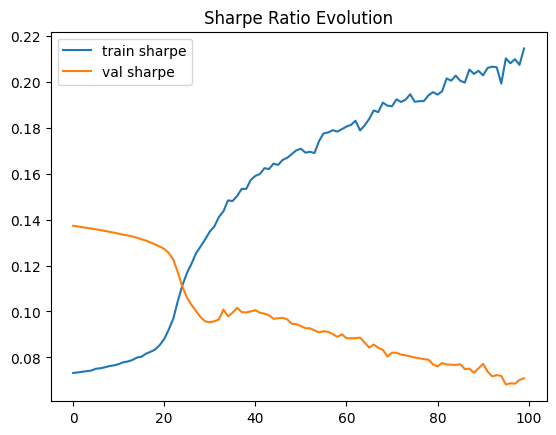

In [412]:
plt.plot(train_sharpe_history, label = 'train sharpe')
plt.plot(val_sharpe_history, label = 'val sharpe')
plt.legend()
plt.title("Sharpe Ratio Evolution")
plt.show()

The above plot suggest that the model is overfitting.

## Overfitting

In [413]:
model.eval()
test_weights = []

with torch.no_grad():
    for batch_X, _ in test_dataset:
        # Get softmax weights
        weights = model(batch_X.float())
        test_weights.append(weights.numpy())

# Combine batches into a single array
# Shape will be (Number of Days, Number of Assets)
test_weights_array = np.concatenate(test_weights, axis=0)

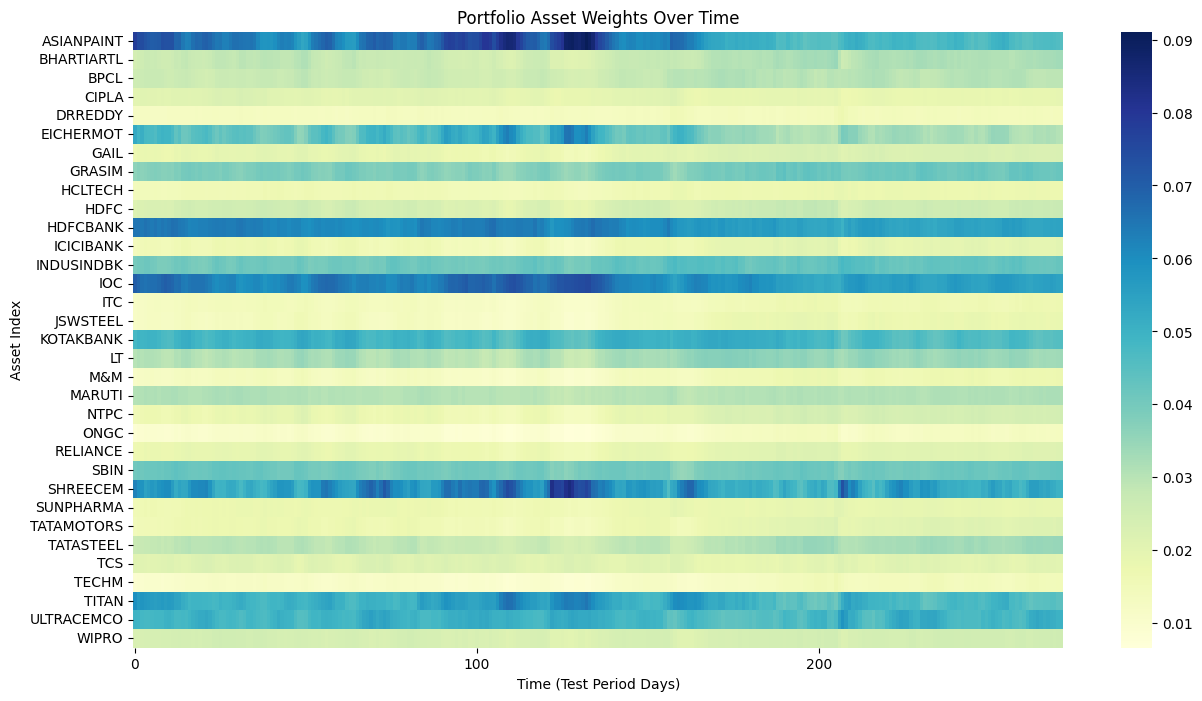

In [414]:
stock_symbols = prices.columns.tolist()
plt.figure(figsize=(15, 8))
sns.heatmap(test_weights_array.T, cmap='YlGnBu', xticklabels=100, yticklabels=stock_symbols)

plt.title('Portfolio Asset Weights Over Time')
plt.xlabel('Time (Test Period Days)')
plt.ylabel('Asset Index')
plt.show()

The heatmap above visualizes the weights allocated by the LSTM model throughout the testing period. The persistent dark horizontal strips indicate that the model relied heavily on a small subset of stocks. Specifically, the visualization reveals that the model overfit by "betting" significantly on assets such as EICHERMOT and SHREECEM. These particular assets likely experienced anomalous growth during the 2007–2019 training window. Consequently, the model learned to chase their individual historical performance rather than developing a generalized risk-management strategy.

Furthermore, because financial data is inherently noisy, the model’s attempt to maximize the Sharpe Ratio within small batches created a source of instability. This resulted in portfolio weights that were potentially more volatile than necessary.

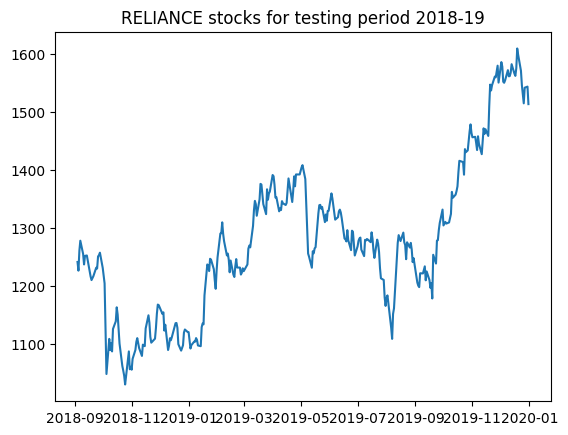

In [415]:
plt.plot(test_prices['RELIANCE'])
plt.title('RELIANCE stocks for testing period 2018-19')
plt.show()

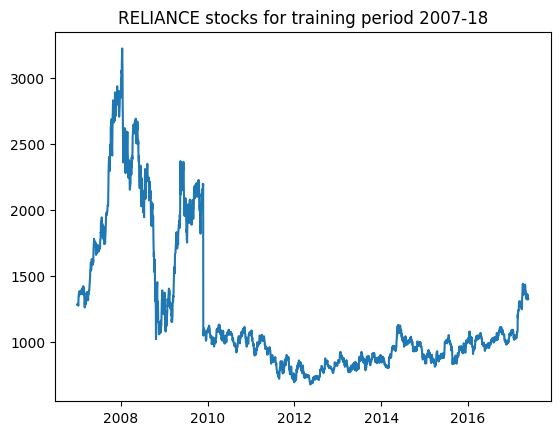

In [416]:
plt.plot(train_prices['RELIANCE'])
plt.title('RELIANCE stocks for training period 2007-18')
plt.show()

The heatmap reveals that RELIANCE was undervalued by the LSTM model, despite the stock exhibiting strong returns during the testing period. This discrepancy is likely a result of overfitting; since RELIANCE performed poorly throughout the 2007–2019 training window, the model learned to associate the asset with low weights. Because the LSTM relies on patterns established in the training data, it failed to adapt to the stock's improved performance in the out-of-sample test set.

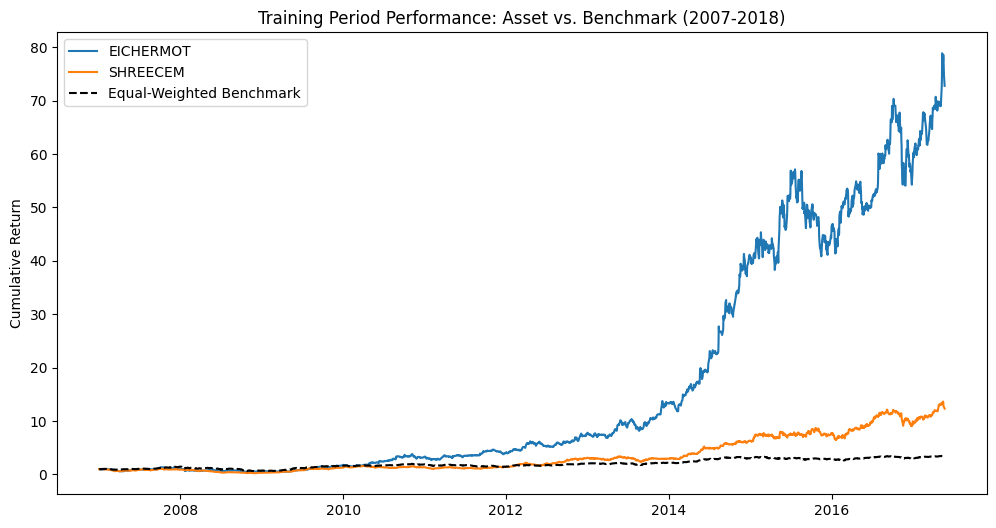

In [ ]:
train_returns = train_prices.pct_change().dropna()

eicher_cum = (1 + train_returns['EICHERMOT']).cumprod()
shree_cum = (1 + train_returns['SHREECEM']).cumprod()
benchmark_cum = (1 + train_returns.mean(axis=1)).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(eicher_cum, label='EICHERMOT')
plt.plot(shree_cum, label='SHREECEM')
plt.plot(benchmark_cum, label='Equal-Weighted Benchmark', linestyle='--', color='black')

plt.title('Training Period Performance: Asset vs. Benchmark (2007-2018)')
plt.legend()
plt.ylabel('Cumulative Return')
plt.show()

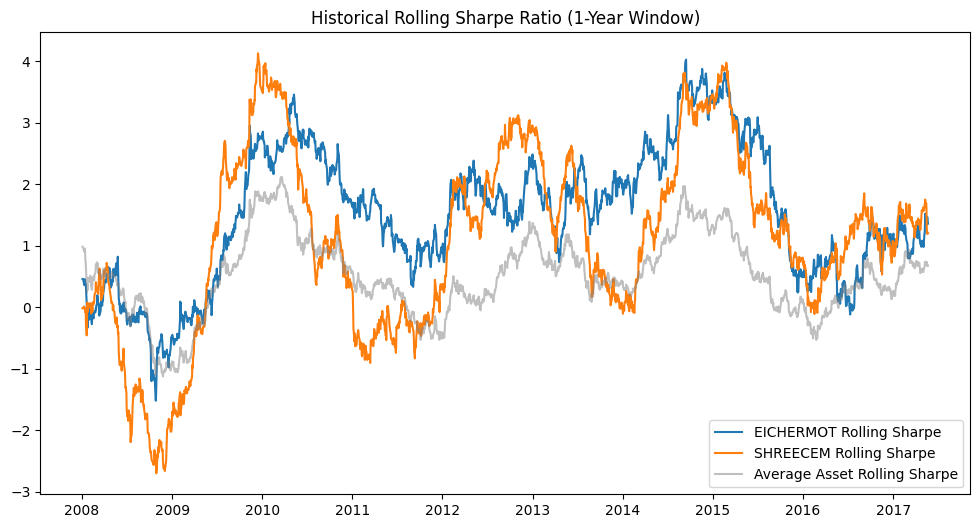

In [418]:
rolling_sharpe = (train_returns.rolling(252).mean() / train_returns.rolling(252).std()) * (252**0.5)

plt.figure(figsize=(12, 6))
plt.plot(rolling_sharpe['EICHERMOT'], label='EICHERMOT Rolling Sharpe')
plt.plot(rolling_sharpe['SHREECEM'], label = 'SHREECEM Rolling Sharpe')
plt.plot(rolling_sharpe.mean(axis=1), label='Average Asset Rolling Sharpe', color='gray', alpha=0.5)
plt.title('Historical Rolling Sharpe Ratio (1-Year Window)')
plt.legend()
plt.show()

### Where did ML improve decisions?

             Strategy  Sharpe Ratio
0          LSTM Model      0.414217
1       Equal Weights      0.183917
2  CVXPY (Max Sharpe)      0.510389


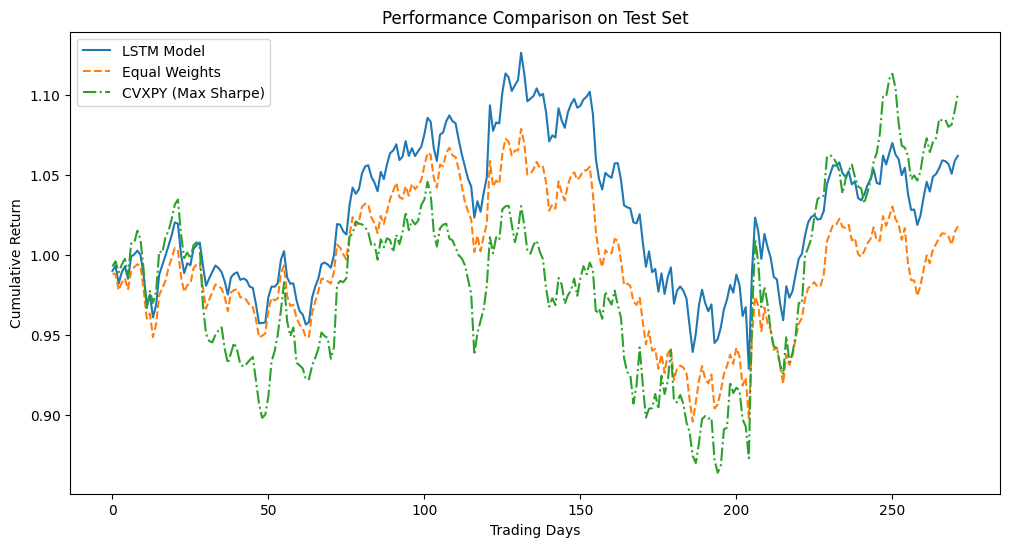

In [419]:
def calculate_sharpe(returns):
    """Calculates the annualized Sharpe Ratio."""
    return np.mean(returns) / (np.std(returns) + 1e-8) * np.sqrt(252)

# 1. LSTM Model Strategy (Dynamic Weights)
model.eval()
model_portfolio_returns = []
with torch.no_grad():
    for batch_X, batch_y in test_dataset:
        weights = model(batch_X.float()) # Output is softmax
        daily_return = torch.sum(weights * batch_y.float(), dim=1) #
        model_portfolio_returns.extend(daily_return.numpy())
model_portfolio_returns = np.array(model_portfolio_returns)

# 2. Equal Weights Strategy (1/N)
n_assets = y_test.shape[1]
equal_weights = np.ones(n_assets) / n_assets
equal_weight_returns = np.dot(y_test, equal_weights)

# 3. CVXPY Max Sharpe Strategy (Markowitz Baseline)
# Estimate mean (mu) and covariance (Sigma) from training data
train_rets = train_prices.pct_change().dropna()
mu = train_rets.mean().values 
Sigma = train_rets.cov().values
n = len(mu)

# Define CVXPY variables and parameters
w_tilde = cp.Variable(n)
# Constraints: mu^T * w_tilde = 1 and w_tilde >= 0 (long-only)
constraints = [cp.matmul(mu, w_tilde) == 1, w_tilde >= 0]
# Objective: Minimize Variance (w_tilde^T * Sigma * w_tilde)
objective = cp.Minimize(cp.quad_form(w_tilde, Sigma))

# Solve with ECOS solver as requested
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.ECOS)

# Transform back to actual portfolio weights (w = w_tilde / sum(w_tilde))
cvx_weights = w_tilde.value / np.sum(w_tilde.value)
cvxpy_returns = np.dot(y_test, cvx_weights)

# 4. Generate Performance Comparison Table
results = pd.DataFrame({
    "Strategy": ["LSTM Model", "Equal Weights", "CVXPY (Max Sharpe)"],
    "Sharpe Ratio": [
        calculate_sharpe(model_portfolio_returns),
        calculate_sharpe(equal_weight_returns),
        calculate_sharpe(cvxpy_returns)
    ]
})
print(results)

# 5. Visualize Cumulative Returns
plt.figure(figsize=(12, 6))
plt.plot((1 + model_portfolio_returns).cumprod(), label='LSTM Model')
plt.plot((1 + equal_weight_returns).cumprod(), label='Equal Weights', linestyle='--')
plt.plot((1 + cvxpy_returns).cumprod(), label='CVXPY (Max Sharpe)', linestyle='-.')
plt.title('Performance Comparison on Test Set')
plt.ylabel('Cumulative Return')
plt.xlabel('Trading Days')
plt.legend()
plt.show()

The above plot evaluates how an initial investment of $1 would have grown over the testing period under three different strategies:LSTM Model, an Equal Weights baseline, and a cvxpy convex optimization.

1. LSTM Model (Dynamic Allocation): Every day, the model looks at the previous 50 days of data and outputs a set of weights $w_{i,t}$. The cumulative return shows the result of those daily reallocations. 
2. Equal Weights ($1/N$ Baseline): This strategy divides the capital equally across all the stocks and never changes the weights. 
3. Convex Optimization: This strategy uses the historical mean and covariance from the training period (2007–2019) to find one "optimal" static weight distribution.

Since the convex optimization approach relies on long-term historical averages, the LSTM improved decisions by identifying short-term temporal dependencies. By linking market information ($x_t$) directly to positions ($w_i$), the model attempted to adapt to changing market regimes rather than assuming the future would mirror the past. This is clear from the above plot. 

**Computing the comulative Returns**<br>
For each day $t$, we take the predicted weights for each asset $i$ ($w_{i,t-1}$) and multiply them by that asset's actual return ($r_{i,t}$):$$R_{p,t} = \sum_{i=1}^{n} w_{i,t-1} \cdot r_{i,t} \quad \text{}.$$ To find the cumulative value at any point in time, we use the cumulative product of the daily growth factors $(1 + R_{p,t})$. 

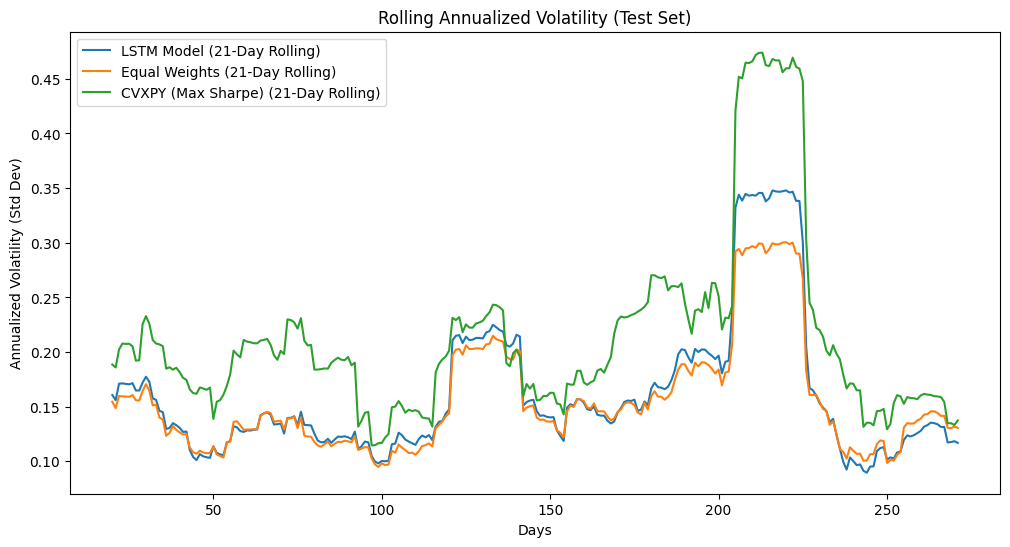

In [420]:
def plot_rolling_volatility(returns_dict, window=21):
    """
    returns_dict: Dictionary of {label: return_array}
    window: Number of days for rolling calculation (e.g., 21 days for a trading month)
    """
    plt.figure(figsize=(12, 6))
    
    for label, rets in returns_dict.items():
        # Calculate rolling standard deviation and annualize it (sqrt(252))
        rolling_vol = pd.Series(rets).rolling(window=window).std() * np.sqrt(252)
        plt.plot(rolling_vol, label=f'{label} ({window}-Day Rolling)')

    plt.title('Rolling Annualized Volatility (Test Set)')
    plt.ylabel('Annualized Volatility (Std Dev)')
    plt.xlabel('Days')
    plt.legend()
    plt.show()

# Usage
strategies = {
    "LSTM Model": model_portfolio_returns,
    "Equal Weights": equal_weight_returns,
    "CVXPY (Max Sharpe)": cvxpy_returns
}
plot_rolling_volatility(strategies)

We also plot the annual rolling volatility to see how risky the model is. The LSTM models is robust because it shows volatility that is comparable to the Equal Weights baseline while maintaining higher returns.

## Model Performance
While the LSTM has the potential to improve performance, the current results suggest it leaned more toward simple historical data based predictions because of the overfitting. In terms of roubustness the model not much better than the equal weights allocation. 

# Pattern Discovery

## Rolling Average

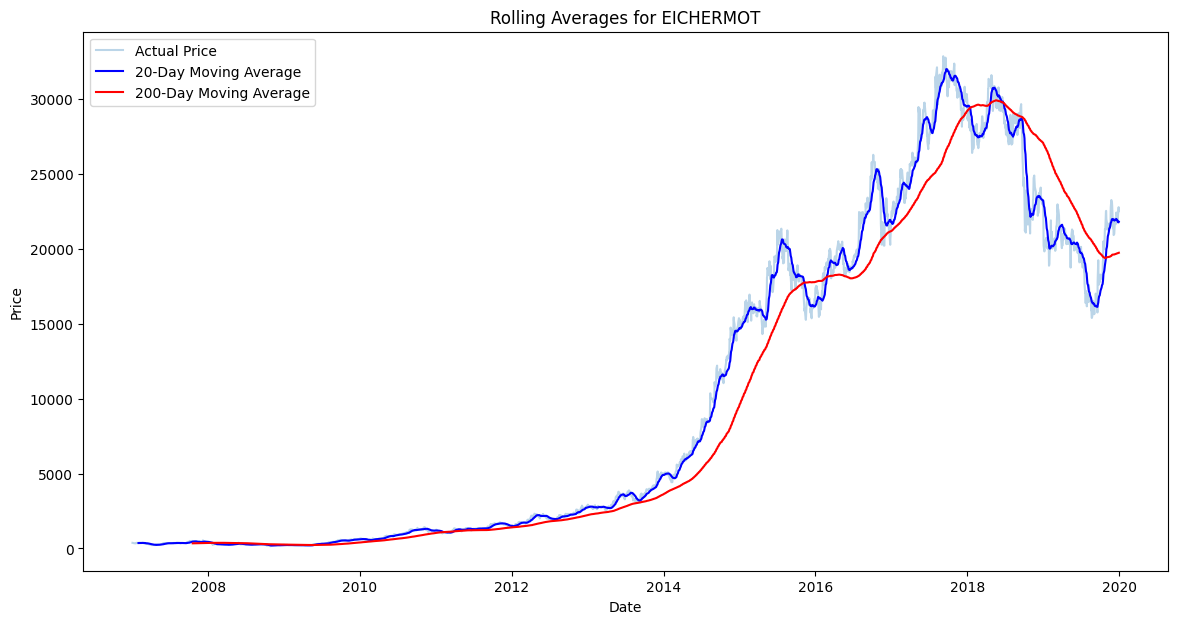

In [ ]:
def plot_moving_averages(data, column_name, short_window=20, long_window=200):
    plt.figure(figsize=(14, 7))
    
    # Raw Price
    plt.plot(data[column_name], label='Actual Price', alpha=0.3)
    
    # Short-term rolling average
    short_ma = data[column_name].rolling(window=short_window).mean()
    plt.plot(short_ma, label=f'{short_window}-Day Moving Average', color='blue')
    
    # Long-term rolling average
    long_ma = data[column_name].rolling(window=long_window).mean()
    plt.plot(long_ma, label=f'{long_window}-Day Moving Average', color='red')
    
    plt.title(f'Rolling Averages for {column_name}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

plot_moving_averages(prices, 'EICHERMOT')

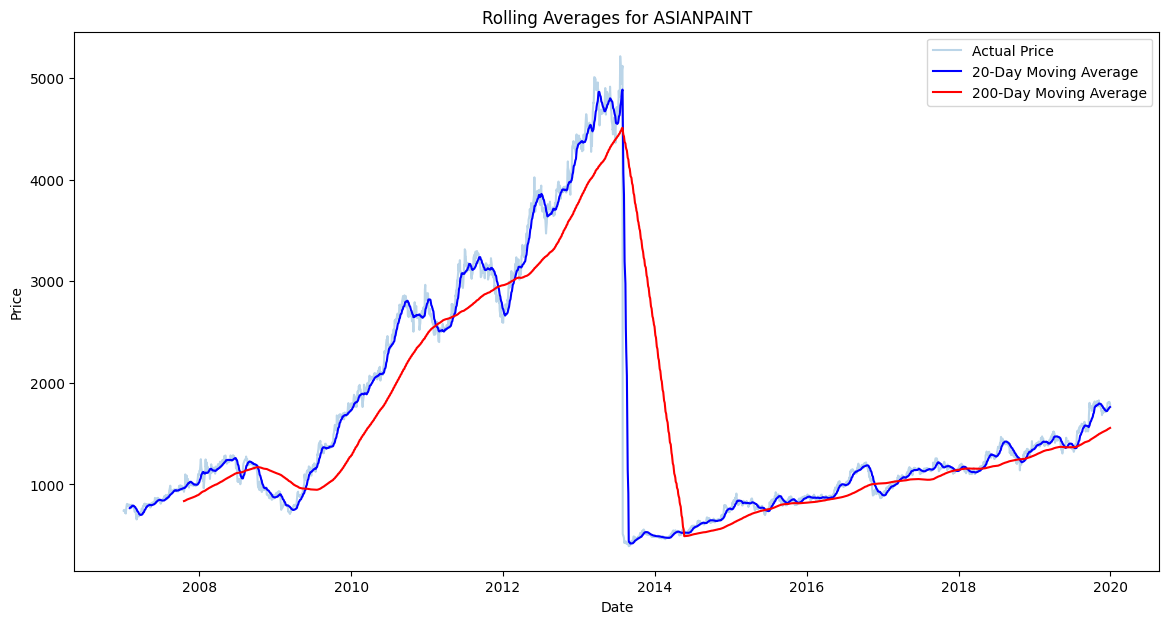

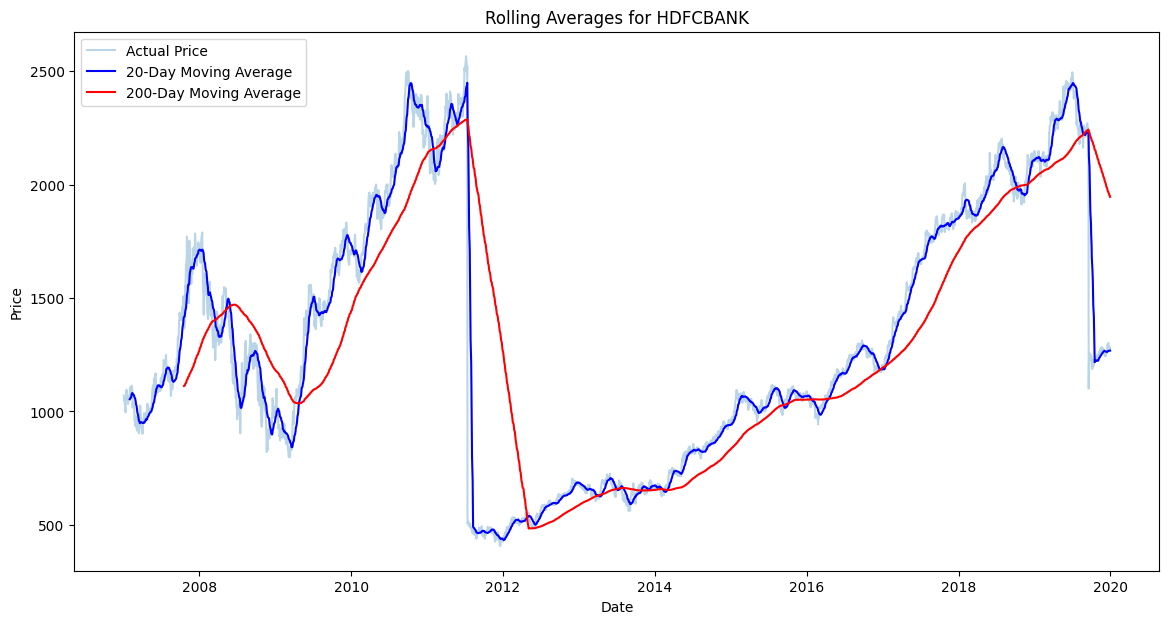

In [445]:
plot_moving_averages(prices, 'ASIANPAINT')
plot_moving_averages(prices, 'HDFCBANK')

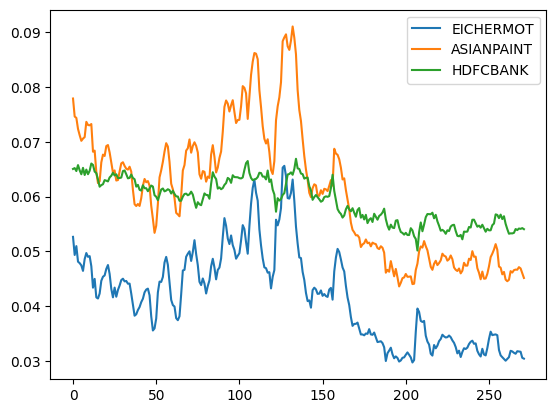

In [444]:
plt.plot(test_weights_array[:,5], label = stock_symbols[5])
plt.plot(test_weights_array[:,0], label = stock_symbols[0])
plt.plot(test_weights_array[:,10], label = stock_symbols[10])
plt.legend()
plt.show()
testing_period = prices.iloc[split_idx+val_split:].index

In [ ]:
testing_period[0], testing_period[-1]

(Timestamp('2018-09-04 00:00:00'), Timestamp('2019-12-31 00:00:00'))

Ideally, the portfolio weights assigned by the model should align with a stock's rolling average trend, provided that volatility remains low.

## Rolling Volatility

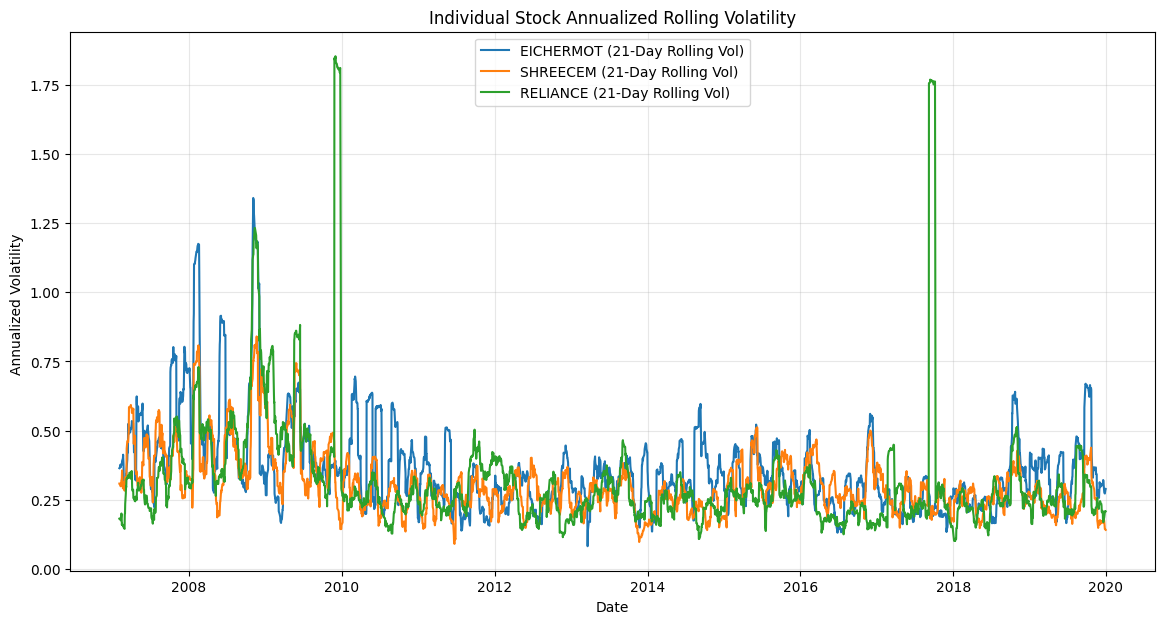

In [449]:
def plot_individual_stock_volatility(data, symbols, window=21):
    plt.figure(figsize=(14, 7))
    
    for symbol in symbols:
        # 1. Calculate Daily Percentage Returns
        daily_returns = data[symbol].pct_change()
        
        # 2. Calculate Rolling Standard Deviation and Annualize (sqrt(252))
        # Formula: Annualized Vol = Daily Std Dev * sqrt(252)
        rolling_vol = daily_returns.rolling(window=window).std() * np.sqrt(252)
        
        plt.plot(rolling_vol, label=f'{symbol} ({window}-Day Rolling Vol)')

    plt.title('Individual Stock Annualized Rolling Volatility')
    plt.ylabel('Annualized Volatility ')
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_individual_stock_volatility(prices, ['EICHERMOT', 'SHREECEM', 'RELIANCE'])